In [64]:
import datasets
from src.model_training.utils import encode_labels
from src.Transform.Padder import Padder
from src.Transform.ListScrambler import ScramblingTransform
from src.Transform.XYZToRGBTensor import XYZToRGBTensor
import importlib
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
def apply_transform(examples_data, examples_labels, real_nr_atoms):
    """Apply transform to each entry in the batch"""
    # Change from XYZ (tensor shape: [28224,3]) to RGB [3,168,168]
    rgb_transformer = XYZToRGBTensor(target_size=168)
    # Scramble with diameter 140A
    scrambler = ScramblingTransform(140)
    # Pad to 168x168 = 28224
    padder = Padder(target_size=168, fill=0)

    examples_data = rgb_transformer(padder(scrambler(examples_data)), real_nr_atoms)
    examples_labels = encode_labels(examples_labels)
    return {"data": examples_data, "labels": examples_labels}

def apply_transform_val(examples_data, examples_labels, real_nr_atoms):
    """Apply transform to each entry in the batch"""
    # Change from XYZ (tensor shape: [28224,3]) to RGB [3,168,168]
    rgb_transformer = XYZToRGBTensor(target_size=168)
    # Pad to 168x168 = 28224
    padder = Padder(target_size=168, fill=0.0)

    examples_data = rgb_transformer(padder(examples_data), real_nr_atoms)
    examples_labels = encode_labels(examples_labels)

    return {"data": examples_data, "labels": examples_labels}

In [67]:
dataset_path = '../data/dataset/full_dataset/train'
ds = datasets.load_from_disk(dataset_path)
data_col = "coordinates"
label_col = "binding_type"
ds = ds.rename_column(data_col, "data").rename_column(label_col, "labels")


In [68]:
import matplotlib.pyplot as plt
import numpy as np
ds1 = ds.select(range(10))
# 10-20 for testing
ds2 = ds.select(range(10))
ds_train = ds1.map(
        apply_transform,
        batch_size=1,
        batched=True,
        input_columns=['data', 'labels', "num_atoms"],
        remove_columns=['pdb_id', 'dpp_class', 'ligand_name', 'num_atoms'],
)
ds_test = ds2.map(
        apply_transform_val,
        batch_size=1,
        batched=True,
        input_columns=['data', 'labels', "num_atoms"],
        remove_columns=['pdb_id', 'dpp_class', 'ligand_name', 'num_atoms'],
)





Map:   0%|          | 0/10 [00:00<?, ? examples/s]

is_list True
4047
4047
is_list True
2817
2817
is_list True
2817
2817
is_list True
4047
4047
is_list True
2817
2817
is_list True
4047
4047
is_list True
2817
2817
is_list True
4047
4047
is_list True
4047
4047
is_list True
4047
4047


In [69]:
def tensor_to_image(tensor):
    """
    Convert a tensor to an image and display it.
    :param tensor: Input tensor of shape (3, height, width)
    :return:
    """

    # Convert tensor to numpy array
    array = tensor.numpy()

    # Transpose the array to (height, width, channels)
    array = np.transpose(array, (1, 2, 0))

    # Display the image
    plt.imshow(array)
    plt.axis('off')  # Hide axis
    plt.show()

In [70]:
examples_data = ds1[0:2]['data']
real_nr_atoms = ds1[0:2]['num_atoms']
labels = ds1[0:2]['labels']

In [71]:
scrambler = ScramblingTransform(140)
scrambled_data = scrambler(examples_data)
scrambled_data[0]

[[-57.49376678466797, -7.388179779052734, -89.78838348388672],
 [-56.88041687011719, -7.570568084716797, -88.9940185546875],
 [-58.193626403808594, -6.675815582275391, -89.59610748291016],
 [-56.844932556152344, -7.0926666259765625, -90.50650024414062],
 [-58.18095397949219, -8.632591247558594, -90.13507080078125],
 [-58.944419860839844, -8.396858215332031, -90.88219451904297],
 [-57.288734436035156, -9.668388366699219, -90.82747650146484],
 [-57.85993194580078, -10.59835433959961, -90.95387268066406],
 [-57.12342071533203, -9.261802673339844, -91.82709503173828],
 [-56.331329345703125, -9.76144027709961, -90.3006362915039],
 [-58.914329528808594, -9.19512939453125, -88.95271301269531],
 [-58.353675842285156, -9.433357238769531, -87.88800048828125],
 [-60.226463317871094, -9.458538055419922, -89.11930847167969],
 [-60.666053771972656, -9.217456817626953, -89.99951171875],
 [-61.10551452636719, -9.994613647460938, -88.08606719970703],
 [-60.81007385253906, -9.499897003173828, -87.150032

In [72]:
padder = Padder(target_size=168, fill=0)
padded_data = padder(scrambled_data)
padded_data[0]

[[-57.49376678466797, -7.388179779052734, -89.78838348388672],
 [-56.88041687011719, -7.570568084716797, -88.9940185546875],
 [-58.193626403808594, -6.675815582275391, -89.59610748291016],
 [-56.844932556152344, -7.0926666259765625, -90.50650024414062],
 [-58.18095397949219, -8.632591247558594, -90.13507080078125],
 [-58.944419860839844, -8.396858215332031, -90.88219451904297],
 [-57.288734436035156, -9.668388366699219, -90.82747650146484],
 [-57.85993194580078, -10.59835433959961, -90.95387268066406],
 [-57.12342071533203, -9.261802673339844, -91.82709503173828],
 [-56.331329345703125, -9.76144027709961, -90.3006362915039],
 [-58.914329528808594, -9.19512939453125, -88.95271301269531],
 [-58.353675842285156, -9.433357238769531, -87.88800048828125],
 [-60.226463317871094, -9.458538055419922, -89.11930847167969],
 [-60.666053771972656, -9.217456817626953, -89.99951171875],
 [-61.10551452636719, -9.994613647460938, -88.08606719970703],
 [-60.81007385253906, -9.499897003173828, -87.150032

In [73]:
img = XYZToRGBTensor(target_size=168)(padded_data, real_nr_atoms)
img[0].shape



is_list True
6864
6864


torch.Size([3, 168, 168])

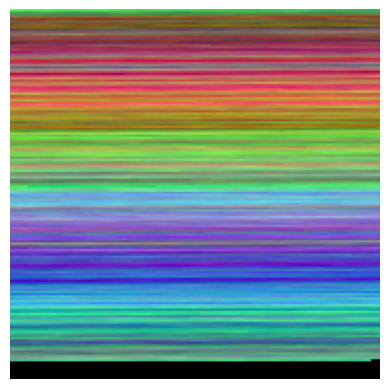

In [74]:
tensor_to_image(img[0])

In [75]:
ds_train.set_format("torch")
ds_test.set_format("torch")

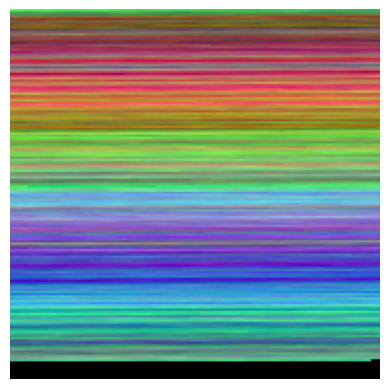

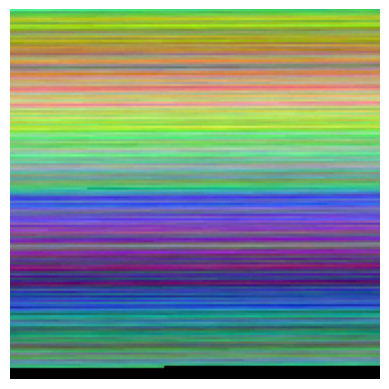

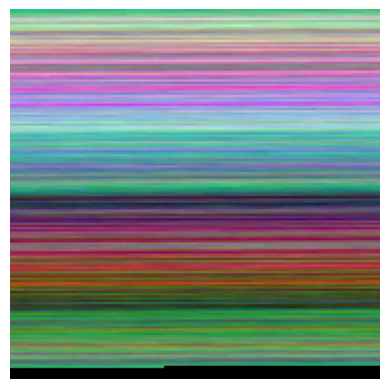

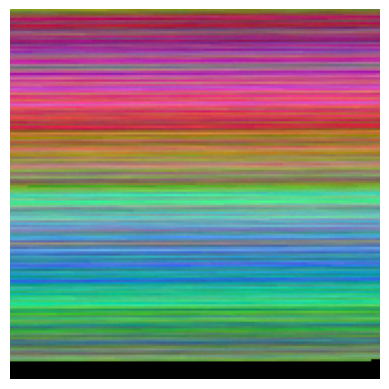

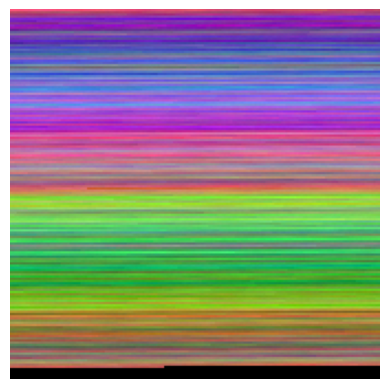

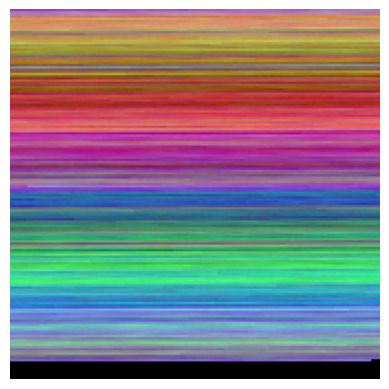

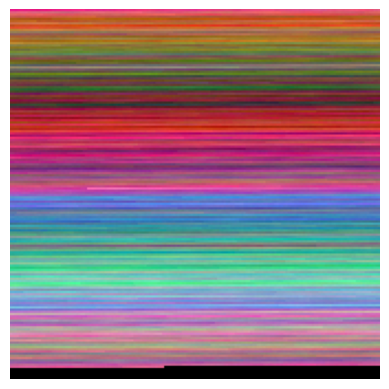

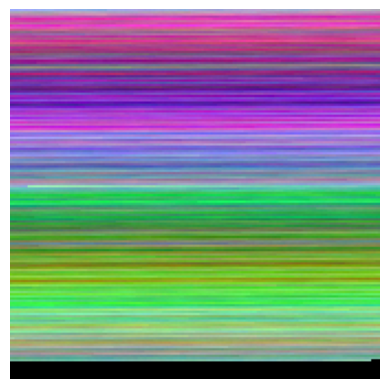

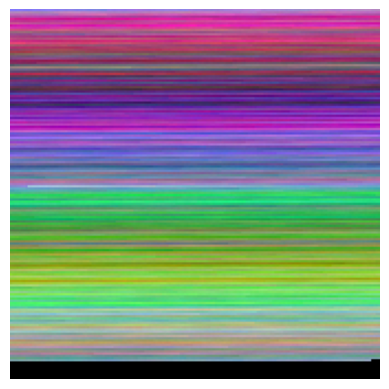

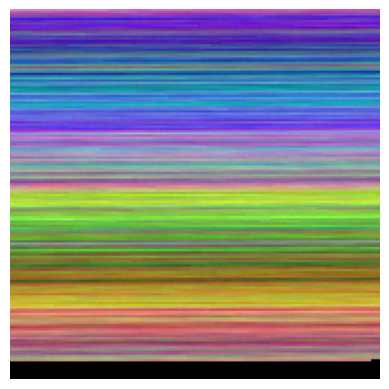

In [76]:
for png in ds_train['data']:
    tensor_to_image(png)



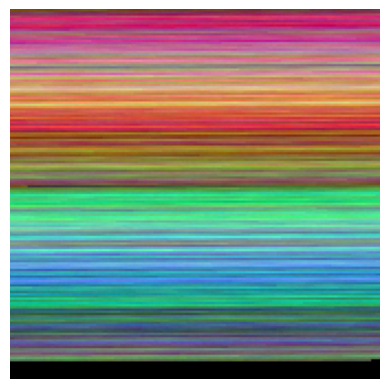

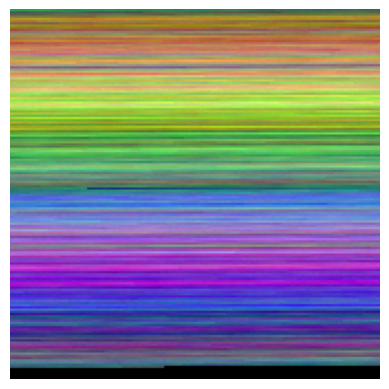

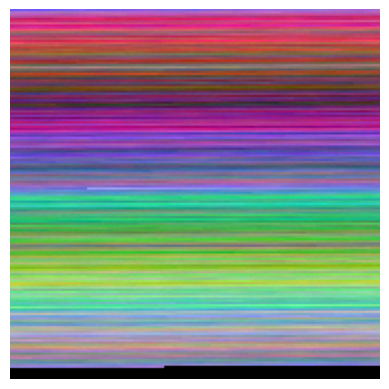

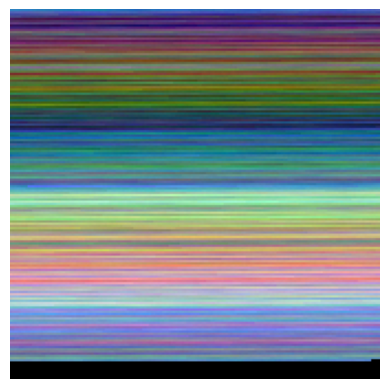

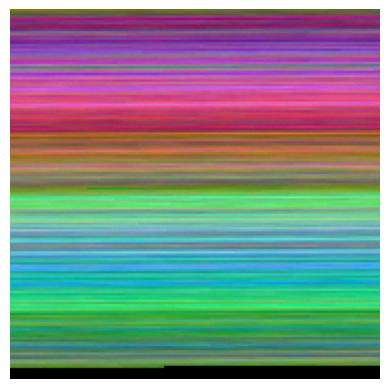

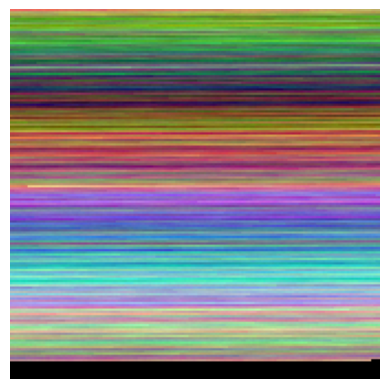

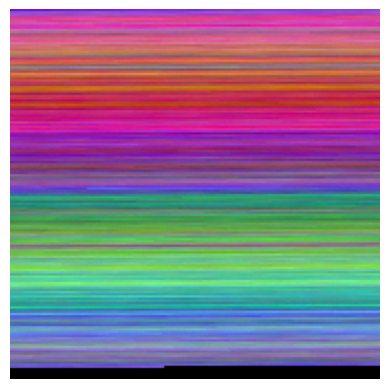

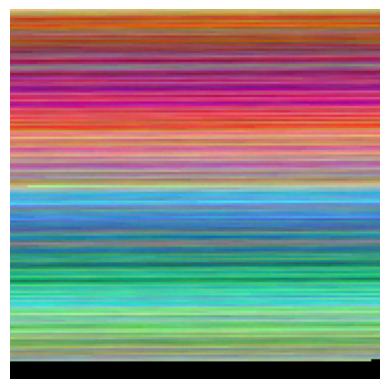

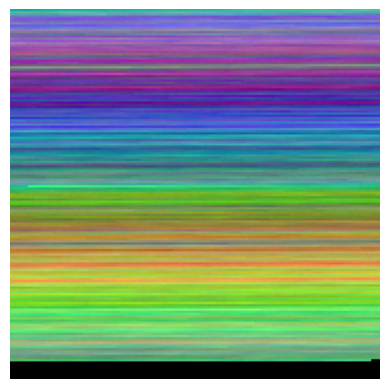

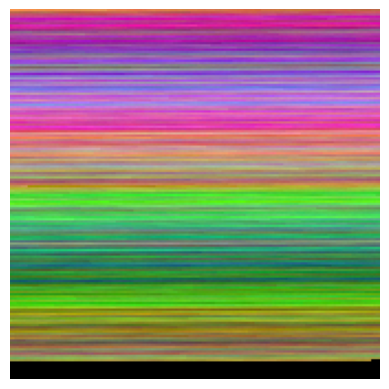

In [77]:
for png in ds_test['data']:
    tensor_to_image(png)